#### remember taker vs maker strat

we need to pick, size of our trades, entry/exit signal, leverage (borrowing money)

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import polars as pl
import numpy as np
from datetime import datetime, timedelta
import random

import torch
import torch.nn as nn
import torch.optim as optim
import research

import altair as alt

import binance

In [2]:
import models

model = models.LinearModel(1)

model.load_state_dict(torch.load('12h_lag3_model.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

### Model Params

In [3]:
research.print_model_params(model)

linear.weight:
[[-0.02531245]]
linear.bias:
[-5.0738487e-05]


### Mean Reversion

In [4]:
series = [-0.014, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


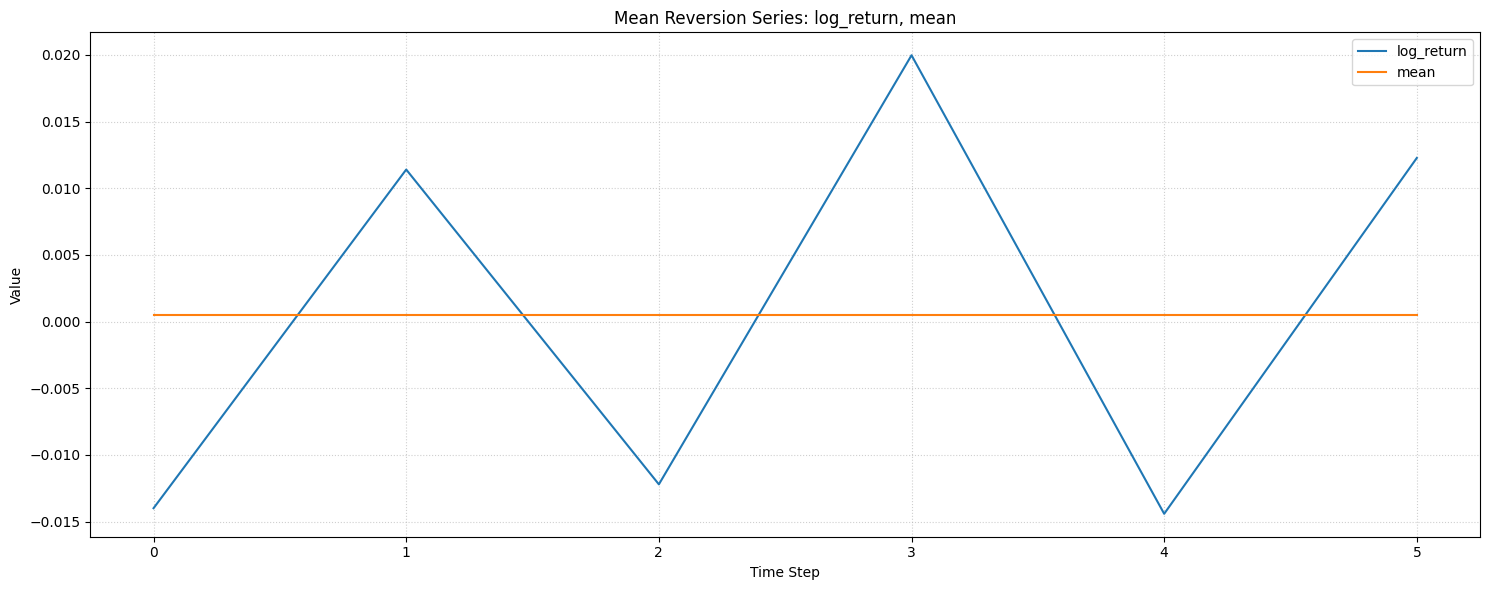

In [5]:
research.plot_multiple_lines(mean_reversion_df, ['log_return', 'mean'], 'Mean Reversion')

## Strategy development

### load time series

In [6]:
sym = 'BTCUSDT'
time_interval='12h'

ts = pl.read_csv(f"../historical_data/{sym}_{time_interval}_ohlc_updated.csv", try_parse_dates=True).sort('datetime')
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,93986.0
2025-05-05 12:00:00,93986.1,95165.1,93559.6,94696.7
2025-05-06 00:00:00,94696.7,94893.3,93662.2,93770.3
2025-05-06 12:00:00,93770.3,96879.5,93327.0,96798.9
2025-05-07 00:00:00,96798.9,97700.0,96153.2,97000.0
…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1


#### add target and features


In [7]:
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,93986.0,null,null,null,null
2025-05-05 12:00:00,93986.1,95165.1,93559.6,94696.7,0.007533,null,null,null
2025-05-06 00:00:00,94696.7,94893.3,93662.2,93770.3,-0.009831,0.007533,null,null
2025-05-06 12:00:00,93770.3,96879.5,93327.0,96798.9,0.031787,-0.009831,0.007533,null
2025-05-07 00:00:00,96798.9,97700.0,96153.2,97000.0,0.002075,0.031787,-0.009831,0.007533
…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412


In [8]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364
…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412


#### strategy decision #1, entry/exit signal

In [9]:
# 1. time based. exit 8 hours later
# 2. predicate based. prediction, but until certain condition is satisfied, make prediction



##### add model predictions

In [10]:
target = 'close_log_return'
features = [f'{target}_lag_3']
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147,-0.000308
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,-0.000367
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.00016
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,0.000709
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.000136
…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,-0.000023
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.000227
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,-0.00004


##### add directional signal

In [11]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades


datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147,-0.000308,-1.0
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,-0.000367,-1.0
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.00016,1.0
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,0.000709,1.0
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.000136,-1.0
…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,-0.000023,-1.0
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.000227,-1.0
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,-0.00004,-1.0


#### calc trade log return

In [12]:
trades= trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147,-0.000308,-1.0,0.030017
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,-0.000367,-1.0,-0.003364
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.00016,1.0,-0.03823
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,0.000709,1.0,-0.039867
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.000136,-1.0,0.111434
…,…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,-0.000023,-1.0,0.001164
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.000227,-1.0,-0.002855
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,-0.00004,-1.0,-0.013528


#### calc cumulative trade log return

In [13]:
trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147,-0.000308,-1.0,0.030017,0.030017
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,-0.000367,-1.0,-0.003364,0.026653
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.00016,1.0,-0.03823,-0.011578
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,0.000709,1.0,-0.039867,-0.051445
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.000136,-1.0,0.111434,0.05999
…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,-0.000023,-1.0,0.001164,0.276396
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.000227,-1.0,-0.002855,0.273542
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,-0.00004,-1.0,-0.013528,0.260014


#### display equity curve (log space)

In [14]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

## Strategy decision #2: Trade sizing

In [15]:
#1. constant trade size
#2. compounding trade size

##### constant sizing

In [16]:
capital = 100
ratio = 1.0
trade_value = ratio * capital

# entry trade value and exit trade value
trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2026-02-03 12:00:00,78040.1,75732.4,0.030017,-0.000308,100.0,103.047177,-0.001281
2026-02-04 00:00:00,75732.4,75987.6,-0.003364,-0.000367,100.0,99.664156,-0.00132
2026-02-04 12:00:00,75987.6,73137.4,-0.03823,0.00016,100.0,96.249125,0.001316
2026-02-05 00:00:00,73137.5,70279.0,-0.039867,0.000709,100.0,96.09174,0.001367
2026-02-05 12:00:00,70279.1,62868.1,0.111434,-0.000136,100.0,111.788013,-0.001423
…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,78529.0,0.001164,-0.000023,100.0,100.116517,-0.001272
2026-05-04 00:00:00,78529.0,78753.5,-0.002855,-0.000227,100.0,99.714933,-0.001273
2026-05-04 12:00:00,78753.5,79826.1,-0.013528,-0.00004,100.0,98.656329,-0.00127


#### add trade gross profit and loss

In [17]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,75732.4,0.030017,-0.000308,100.0,103.047177,-0.001281,3.047177
2026-02-04 00:00:00,75732.4,75987.6,-0.003364,-0.000367,100.0,99.664156,-0.00132,-0.335844
2026-02-04 12:00:00,75987.6,73137.4,-0.03823,0.00016,100.0,96.249125,0.001316,-3.750875
2026-02-05 00:00:00,73137.5,70279.0,-0.039867,0.000709,100.0,96.09174,0.001367,-3.90826
2026-02-05 12:00:00,70279.1,62868.1,0.111434,-0.000136,100.0,111.788013,-0.001423,11.788013
…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,78529.0,0.001164,-0.000023,100.0,100.116517,-0.001272,0.116517
2026-05-04 00:00:00,78529.0,78753.5,-0.002855,-0.000227,100.0,99.714933,-0.001273,-0.285067
2026-05-04 12:00:00,78753.5,79826.1,-0.013528,-0.00004,100.0,98.656329,-0.00127,-1.343671


#### Add transaction fees 

In [18]:
taker_fee = binance.TAKER_FEE
maker_fee = binance.MAKER_FEE

trades = trades.with_columns(
    ((pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee) * pl.col('dir_signal').abs()).alias('taker_fee'),
    ((pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee) * pl.col('dir_signal').abs()).alias('maker_fee')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'maker_fee', 'taker_fee')


datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,75732.4,0.030017,-0.000308,100.0,103.047177,-0.001281,3.047177,0.091371,0.091371
2026-02-04 00:00:00,75732.4,75987.6,-0.003364,-0.000367,100.0,99.664156,-0.00132,-0.335844,0.089849,0.089849
2026-02-04 12:00:00,75987.6,73137.4,-0.03823,0.00016,100.0,96.249125,0.001316,-3.750875,0.088312,0.088312
2026-02-05 00:00:00,73137.5,70279.0,-0.039867,0.000709,100.0,96.09174,0.001367,-3.90826,0.088241,0.088241
2026-02-05 12:00:00,70279.1,62868.1,0.111434,-0.000136,100.0,111.788013,-0.001423,11.788013,0.095305,0.095305
…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,78529.0,0.001164,-0.000023,100.0,100.116517,-0.001272,0.116517,0.090052,0.090052
2026-05-04 00:00:00,78529.0,78753.5,-0.002855,-0.000227,100.0,99.714933,-0.001273,-0.285067,0.089872,0.089872
2026-05-04 12:00:00,78753.5,79826.1,-0.013528,-0.00004,100.0,98.656329,-0.00127,-1.343671,0.089395,0.089395


##### calc net trade pnl

In [19]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('maker_fee')).alias('trade_net_maker_pnl'),
    (pl.col('trade_gross_pnl') - pl.col('taker_fee')).alias('trade_net_taker_pnl'),
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'trade_net_taker_pnl', 'trade_net_maker_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,75732.4,0.030017,-0.000308,100.0,103.047177,-0.001281,3.047177,2.955805,2.955805
2026-02-04 00:00:00,75732.4,75987.6,-0.003364,-0.000367,100.0,99.664156,-0.00132,-0.335844,-0.425693,-0.425693
2026-02-04 12:00:00,75987.6,73137.4,-0.03823,0.00016,100.0,96.249125,0.001316,-3.750875,-3.839187,-3.839187
2026-02-05 00:00:00,73137.5,70279.0,-0.039867,0.000709,100.0,96.09174,0.001367,-3.90826,-3.996502,-3.996502
2026-02-05 12:00:00,70279.1,62868.1,0.111434,-0.000136,100.0,111.788013,-0.001423,11.788013,11.692709,11.692709
…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,78529.0,0.001164,-0.000023,100.0,100.116517,-0.001272,0.116517,0.026465,0.026465
2026-05-04 00:00:00,78529.0,78753.5,-0.002855,-0.000227,100.0,99.714933,-0.001273,-0.285067,-0.374938,-0.374938
2026-05-04 12:00:00,78753.5,79826.1,-0.013528,-0.00004,100.0,98.656329,-0.00127,-1.343671,-1.433066,-1.433066


#### display equity curves for constant sizing

In [20]:
def equity_curve(capital, col_name, suffix):
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)

trades.select('datetime', 'equity_curve_gross', 'equity_curve_taker', 'equity_curve_maker')

datetime,equity_curve_gross,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64
2026-02-03 12:00:00,103.047177,102.955805,102.955805
2026-02-04 00:00:00,102.711332,102.530112,102.530112
2026-02-04 12:00:00,98.960457,98.690925,98.690925
2026-02-05 00:00:00,95.052197,94.694423,94.694423
2026-02-05 12:00:00,106.84021,106.387132,106.387132
…,…,…,…
2026-05-03 12:00:00,131.115643,114.991641,114.991641
2026-05-04 00:00:00,130.830577,114.616703,114.616703
2026-05-04 12:00:00,129.486906,113.183637,113.183637


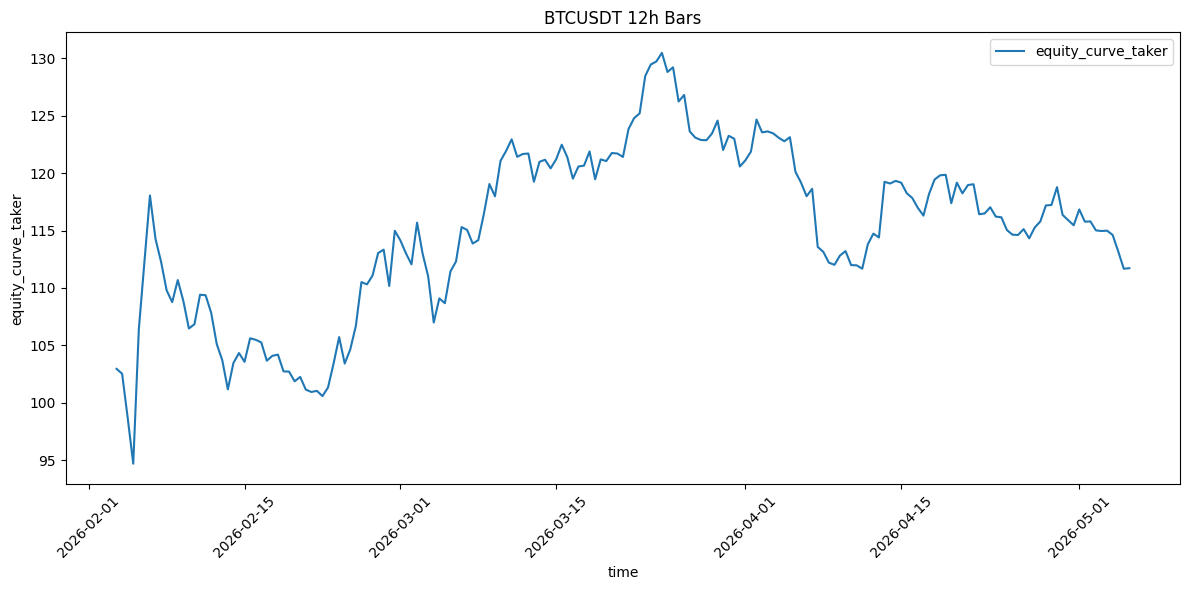

In [21]:
research.plot_static_timeseries(trades, sym, 'equity_curve_taker',time_interval)

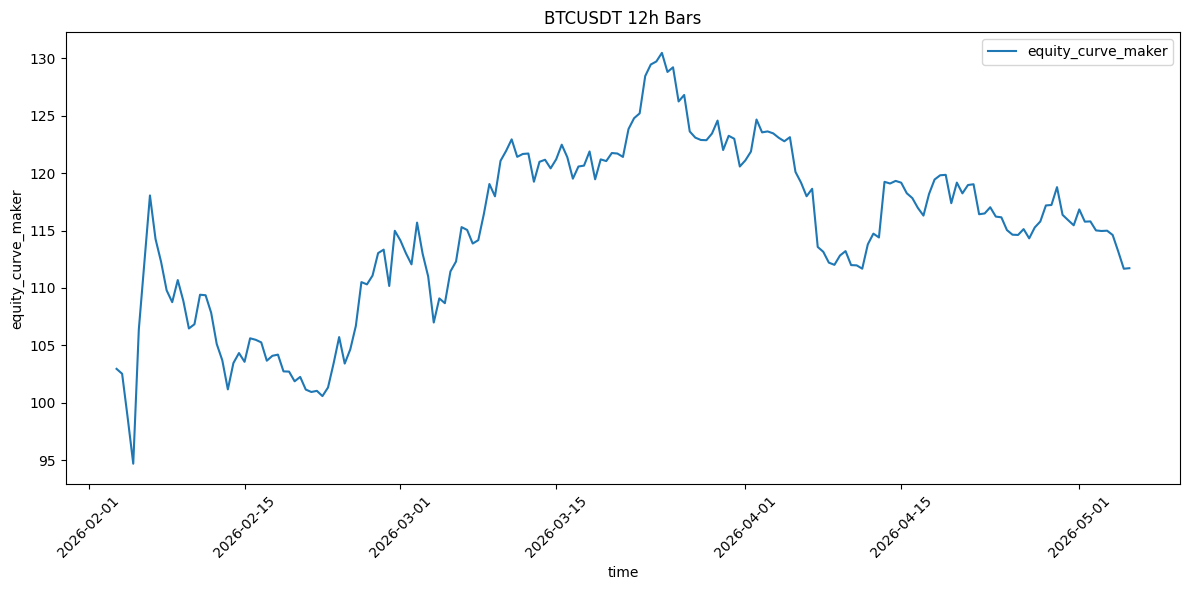

In [22]:
research.plot_static_timeseries(trades, sym, 'equity_curve_maker',time_interval)

### calculate total net return using constant sizing

In [23]:
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
constant_sizing_net_return

0.11725208848699742

#### compounding trade sizing

reinvesting earnings basically.

- if you put in 100, and earn two, your next trade you would put in 102
- principle of time additivity

In [24]:
trades = trades.with_columns(
    ((pl.col('cum_trade_log_return').exp()) * capital).shift().fill_null(capital).alias('entry_trade_value'),
    ((pl.col('cum_trade_log_return').exp()) * capital).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,75732.4,0.030017,100.0,103.047177,-0.001281,3.047177
2026-02-04 00:00:00,75732.4,75987.6,-0.003364,103.047177,102.701099,-0.001361,-0.346078
2026-02-04 12:00:00,75987.6,73137.4,-0.03823,102.701099,98.848909,0.001352,-3.85219
2026-02-05 00:00:00,73137.5,70279.0,-0.039867,98.848909,94.985636,0.001352,-3.863273
2026-02-05 12:00:00,70279.1,62868.1,0.111434,94.985636,106.182555,-0.001352,11.196919
…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,78529.0,0.001164,131.683614,131.837048,-0.001675,0.153434
2026-05-04 00:00:00,78529.0,78753.5,-0.002855,131.837048,131.461224,-0.001679,-0.375824
2026-05-04 12:00:00,78753.5,79826.1,-0.013528,131.461224,129.694818,-0.001669,-1.766406


##### add transaction fees

In [25]:
trades = research.add_tx_fees(trades, binance.MAKER_FEE, binance.TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2026-02-03 12:00:00,100.0,103.047177,0.091371,0.091371
2026-02-04 00:00:00,103.047177,102.701099,0.092587,0.092587
2026-02-04 12:00:00,102.701099,98.848909,0.090698,0.090698
2026-02-05 00:00:00,98.848909,94.985636,0.087226,0.087226
2026-02-05 12:00:00,94.985636,106.182555,0.090526,0.090526
…,…,…,…,…
2026-05-03 12:00:00,131.683614,131.837048,0.118584,0.118584
2026-05-04 00:00:00,131.837048,131.461224,0.118484,0.118484
2026-05-04 12:00:00,131.461224,129.694818,0.11752,0.11752


#### add trade net pnl

In [26]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)

trades.select('datetime', 'open', 'close', 'close_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'trade_net_taker_pnl')

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,trade_gross_pnl,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,75732.4,-0.030017,-0.000308,100.0,103.047177,3.047177,2.955805
2026-02-04 00:00:00,75732.4,75987.6,0.003364,-0.000367,103.047177,102.701099,-0.346078,-0.438665
2026-02-04 12:00:00,75987.6,73137.4,-0.03823,0.00016,102.701099,98.848909,-3.85219,-3.942887
2026-02-05 00:00:00,73137.5,70279.0,-0.039867,0.000709,98.848909,94.985636,-3.863273,-3.950498
2026-02-05 12:00:00,70279.1,62868.1,-0.111434,-0.000136,94.985636,106.182555,11.196919,11.106394
…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,78529.0,-0.001164,-0.000023,131.683614,131.837048,0.153434,0.03485
2026-05-04 00:00:00,78529.0,78753.5,0.002855,-0.000227,131.837048,131.461224,-0.375824,-0.494308
2026-05-04 12:00:00,78753.5,79826.1,0.013528,-0.00004,131.461224,129.694818,-1.766406,-1.883926


### Display equity curve (compounding)

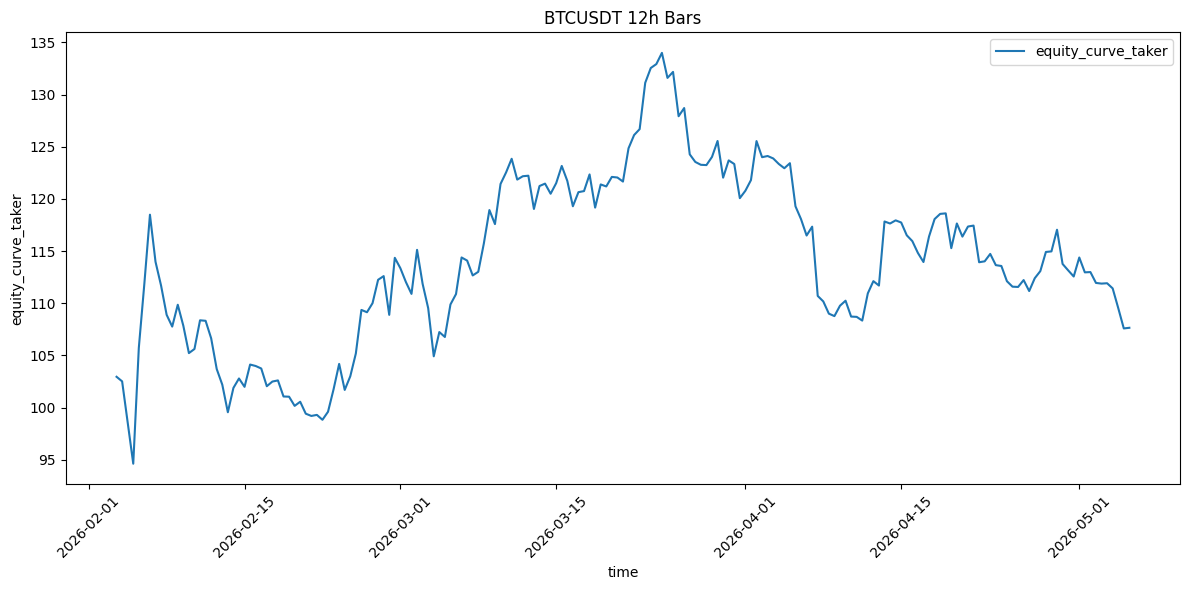

In [27]:
trades = research.add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

### calculate total net return for compounding trade sizing

In [28]:
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
compound_total_net_return

0.07651704792886527

In [29]:
constant_sizing_net_return

0.11725208848699742

In [30]:
np.round(compound_total_net_return - constant_sizing_net_return, 3)

np.float64(-0.041)

### Strategy decision #3, leverage

borrowing money?


In [31]:
leverage = 4
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147,-0.000308,-1.0,0.030017,0.030017,400.0,412.188707,0.001281,-0.005126,12.188707,0.091371,0.091371,11.823222,11.823222,111.823222,111.823222,112.188707,0.365485,0.365485
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,-0.000367,-1.0,-0.003364,0.026653,412.188707,410.804394,0.00132,-0.005443,-1.384312,0.089849,0.089849,-1.754659,-1.754659,110.068563,110.068563,110.804394,0.370347,0.370347
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.00016,1.0,-0.03823,-0.011578,410.804394,395.395634,0.001316,0.005406,-15.40876,0.088312,0.088312,-15.77155,-15.77155,94.297013,94.297013,95.395634,0.36279,0.36279
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,0.000709,1.0,-0.039867,-0.051445,395.395634,379.942544,0.001367,0.005406,-15.453091,0.088241,0.088241,-15.801993,-15.801993,78.49502,78.49502,79.942544,0.348902,0.348902
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.000136,-1.0,0.111434,0.05999,379.942544,424.730221,0.001423,-0.005406,44.787678,0.095305,0.095305,44.425575,44.425575,122.920595,122.920595,124.730221,0.362103,0.362103
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,-0.000023,-1.0,0.001164,0.276396,526.734454,527.348192,0.001272,-0.0067,0.613738,0.090052,0.090052,0.1394,0.1394,147.689254,147.689254,227.348192,0.474337,0.474337
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.000227,-1.0,-0.002855,0.273542,527.348192,525.844898,0.001273,-0.006715,-1.503294,0.089872,0.089872,-1.977231,-1.977231,145.712023,145.712023,225.844898,0.473937,0.473937
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,-0.00004,-1.0,-0.013528,0.260014,525.844898,518.779274,0.00127,-0.006677,-7.065624,0.089395,0.089395,-7.535705,-7.535705,138.176318,138.176318,218.779274,0.470081,0.470081


#### calculate total net return

In [32]:
trades['equity_curve_taker'][-1] / capital -1

0.3060681917154613

#### increase to 8x leverage? (US legal limit)

In [33]:
leverage = 8
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,-0.030017,-0.008325,0.012485,0.010147,-0.000308,-1.0,0.030017,0.030017,800.0,824.377413,0.001281,-0.010251,24.377413,0.091371,0.091371,23.646443,23.646443,123.646443,123.646443,124.377413,0.73097,0.73097
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,-0.000367,-1.0,-0.003364,0.026653,824.377413,821.608789,0.00132,-0.010885,-2.768624,0.089849,0.089849,-3.509318,-3.509318,120.137125,120.137125,121.608789,0.740694,0.740694
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.00016,1.0,-0.03823,-0.011578,821.608789,790.791269,0.001316,0.010812,-30.81752,0.088312,0.088312,-31.5431,-31.5431,88.594025,88.594025,90.791269,0.72558,0.72558
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,0.000709,1.0,-0.039867,-0.051445,790.791269,759.885087,0.001367,0.010812,-30.906182,0.088241,0.088241,-31.603986,-31.603986,56.990039,56.990039,59.885087,0.697804,0.697804
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.000136,-1.0,0.111434,0.05999,759.885087,849.460443,0.001423,-0.010812,89.575355,0.095305,0.095305,88.85115,88.85115,145.841189,145.841189,149.460443,0.724205,0.724205
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,-0.000023,-1.0,0.001164,0.276396,1053.468909,1054.696384,0.001272,-0.013399,1.227475,0.090052,0.090052,0.278801,0.278801,195.378509,195.378509,354.696384,0.948674,0.948674
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.000227,-1.0,-0.002855,0.273542,1054.696384,1051.689796,0.001273,-0.013431,-3.006588,0.089872,0.089872,-3.954462,-3.954462,191.424047,191.424047,351.689796,0.947874,0.947874
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,-0.00004,-1.0,-0.013528,0.260014,1051.689796,1037.558547,0.00127,-0.013354,-14.131249,0.089395,0.089395,-15.07141,-15.07141,176.352636,176.352636,337.558547,0.940162,0.940162


In [34]:
trades['equity_curve_taker'][-1] / capital -1

0.612136383430923

##### wr hasnt changed

In [35]:
trades.select((pl.col('trade_log_return') > 0).mean())

trade_log_return
f64
0.530055


##### basic liquidation model

closing a position

In [36]:
maintenance_margin = 0.005

def long_liquidation_price(p, l, mmr):
    return (p * l) / (l + 1 - mmr * l)

def short_liquidation_price(p, l, mmr):
    return (p * l) / (l - 1 + mmr * 1)

##### show how leverage affects long positions

In [37]:
long_liquidation_price(200, 2, maintenance_margin)

133.7792642140468

In [38]:
long_liquidation_price(200, 4, maintenance_margin)

160.64257028112448

In [39]:
long_liquidation_price(200, 10, maintenance_margin)

182.64840182648402

#### show how leverage affects short positions

In [40]:
short_liquidation_price(200, 2, maintenance_margin)

398.00995024875624

In [41]:
short_liquidation_price(200, 4, maintenance_margin)

266.22296173044924

### add liquidation prices

In [42]:
leverage = 4

In [43]:
trades = trades.with_columns(
    pl.when(pl.col('dir_signal') == 1)
    .then(
        (pl.col('open') * leverage) / (leverage + 1 - maintenance_margin * leverage)
    )
    .when(pl.col('dir_signal') == -1)
    .then(
        (pl.col('open') * leverage) / (leverage - 1 + maintenance_margin * leverage )
    )
    .otherwise(None)
    .alias('liquidation_price')
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,103364.370861,-1.0
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,100307.81457,-1.0
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,61034.216867,1.0
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,58744.97992,1.0
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,93084.900662,-1.0
…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,104133.245033,-1.0
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,104011.92053,-1.0
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,104309.271523,-1.0


### add liquidation flag

In [44]:
trades = trades.with_columns([
    # worst price based on direction
    pl.when(pl.col('dir_signal') == 1)
        .then(pl.col('low'))
        .otherwise(pl.col('high'))
        .alias('worst_price'),
    # liquidation flag
    pl.when(
        (pl.col('dir_signal') == 1) & (pl.col('low') <= pl.col('liquidation_price'))
    )
    .then(True)
    .when(
        (pl.col('dir_signal') == -1) & (pl.col('high') >= pl.col('liquidation_price'))
    )
    .then(True)
    .otherwise(False)
    .alias('liquidated')
])

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal', 'worst_price', 'liquidated')


datetime,open,high,low,close,liquidation_price,dir_signal,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f32,f64,bool
2026-02-03 12:00:00,78040.1,78425.8,72889.2,75732.4,103364.370861,-1.0,78425.8,false
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,100307.81457,-1.0,76952.5,false
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,61034.216867,1.0,71838.0,false
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,58744.97992,1.0,69862.0,false
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,93084.900662,-1.0,70848.6,false
…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,104133.245033,-1.0,79428.9,false
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,104011.92053,-1.0,80590.2,false
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,104309.271523,-1.0,80771.7,false


### find liquidated trades

In [45]:
trades.filter(pl.col('liquidated') == True)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
